In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("Coffe_sales.csv")
df.head()

,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time
0,10,card,38.7,Latte,Morning,Fri,Mar,5,3,2024-03-01,10:15:50.520000
1,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:19:22.539000
2,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:20:18.089000
3,13,card,28.9,Americano,Afternoon,Fri,Mar,5,3,2024-03-01,13:46:33.006000
4,13,card,38.7,Latte,Afternoon,Fri,Mar,5,3,2024-03-01,13:48:14.626000


<Axes: title={'center': 'Daily Revenue Trend'}, xlabel='Date'>

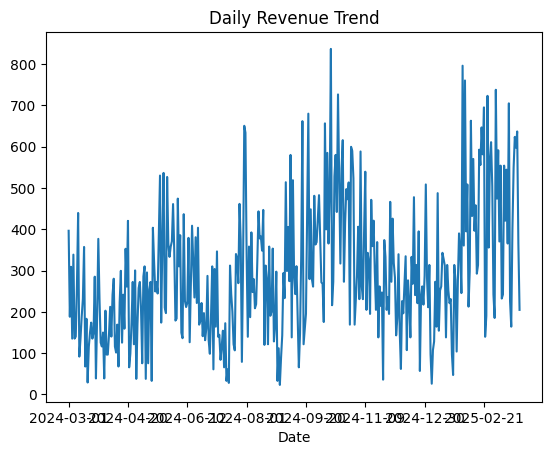

In [47]:
#most revenue on the time of day
gb = df.groupby(['Time_of_Day','coffee_name'])
gb.agg(avg_price=("money","mean"),
       min_price =('money','min'),
       max_price = ('money','max'),
       total = ('money','sum'))
gb = df.groupby('coffee_name')
gb['money'].mean()
gb['money'].sum().idxmax()
import matplotlib.pyplot as plt
df.groupby('Date')['money'].sum().plot(title='Daily Revenue Trend')

In [57]:
df['Date'] = pd.to_datetime(df['Date'])
#daily revenue
df.groupby('Date')['money'].sum()
#weekly 
df.groupby(df['Date'].dt.isocalendar().week)["money"].sum()
#monthly
df.groupby(['Monthsort','Month_name'])['money'].sum().reset_index().sort_values('Monthsort')
# Drop Monthsort after sorting, keep only Month_name as index
monthly_revenue = df.groupby('Month_name')['money'].sum()

# Reorder using Monthsort
month_order = df.drop_duplicates('Month_name').sort_values('Monthsort')['Month_name']

monthly_revenue.reindex(month_order.values)

Month_name
Jan     6398.86
Feb    13215.48
Mar    15891.64
Apr     5719.56
May     8164.42
Jun     7617.76
Jul     6915.94
Aug     7613.84
Sep     9988.64
Oct    13891.16
Nov     8590.54
Dec     8237.74
Name: money, dtype: float64

In [ ]:
#time based
df.groupby('hour_of_day')['money'].sum().sort_values(ascending=False)
df.groupby('hour_of_day').size()
df.groupby(['hour_of_day','coffee_name'])['coffee_name'].value_counts().sort_values(ascending=False)
df.groupby(['Monthsort','Month_name'])['money']
df.groupby(['Weekdaysort','Weekday'])
